# Session 3 — D(x) Nonlinear Element Test Plots\n**Lab 3: Chaotic Circuits** | PHYS 382 Advanced Lab\n\nPlots the D(x) test waveforms captured on the Siglent SDS2352X-E oscilloscope.\n- **CH1 (Yellow):** Input signal\n- **CH2 (Magenta):** Output through D(x) nonlinear element\n- Two captures: Zoom-in (0.1 µs/div) and Zoom-out (100 µs/div)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re

# Paths
DATA_DIR = Path(r"D:\Documents\SFU\PHYS382-AdvancedLab\phys332w-sfu-GIT\phys332W-sfu\Lab3-Chaotic-Circuits\Data\Session-3")
FIG_DIR  = Path(r"D:\Documents\SFU\PHYS382-AdvancedLab\phys332w-sfu-GIT\phys332W-sfu\Lab3-Chaotic-Circuits\Analysis\figures\Session3")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# CSV files
zoom_in_file  = DATA_DIR / "Test-D_x-Zoom-in-SDS00002.csv"
zoom_out_file = DATA_DIR / "Test-D_x-Zoom-out-SDS00003.csv"

def parse_ch_values(raw_str):
    """Parse 'CH1:+5.000000E-01 CH2:+2.000000E-01' into (ch1_val, ch2_val)."""
    matches = re.findall(r'CH(\d):([+-]?\d+\.\d+E[+-]\d+)', raw_str)
    vals = {int(ch): float(v) for ch, v in matches}
    return vals.get(1, 0.0), vals.get(2, 0.0)

def load_siglent_csv(filepath):
    """Load Siglent oscilloscope CSV, extracting metadata and waveform data."""
    meta = {}
    with open(filepath, 'r') as f:
        for i, line in enumerate(f):
            if i < 12:
                parts = line.strip().split(',', 1)  # split only on first comma
                if len(parts) == 2:
                    meta[parts[0]] = parts[1].rstrip(',')
            else:
                break
    
    df = pd.read_csv(filepath, skiprows=12, header=None, names=['Time_s', 'CH1_V', 'CH2_V'])
    
    h_scale = float(meta.get('Horizontal Scale', '0').strip())
    v_scale_ch1, v_scale_ch2 = parse_ch_values(meta.get('Vertical Scale', ''))
    v_offset_ch1, v_offset_ch2 = parse_ch_values(meta.get('Vertical Offset', ''))
    
    info = {
        'h_scale': h_scale,
        'v_scale_ch1': v_scale_ch1,
        'v_scale_ch2': v_scale_ch2,
        'v_offset_ch1': v_offset_ch1,
        'v_offset_ch2': v_offset_ch2,
        'record_length': meta.get('Record Length', ''),
    }
    return df, info

df_in, meta_in   = load_siglent_csv(zoom_in_file)
df_out, meta_out = load_siglent_csv(zoom_out_file)

print(f"Zoom-in:  {len(df_in)} pts, H-scale={meta_in['h_scale']} us/div")
print(f"Zoom-out: {len(df_out)} pts, H-scale={meta_out['h_scale']} us/div")
print(f"CH1 V-scale: {meta_in['v_scale_ch1']} V/div, offset: {meta_in['v_offset_ch1']} V")
print(f"CH2 V-scale: {meta_in['v_scale_ch2']} V/div, offset: {meta_in['v_offset_ch2']} V")
print(f"\nCH1 range: [{df_out['CH1_V'].min():.3f}, {df_out['CH1_V'].max():.3f}] V")
print(f"CH2 raw range: [{df_out['CH2_V'].min():.3f}, {df_out['CH2_V'].max():.3f}] V")
print(f"CH2 corrected range: [{df_out['CH2_V'].min()+meta_out['v_offset_ch2']:.3f}, {df_out['CH2_V'].max()+meta_out['v_offset_ch2']:.3f}] V")

Zoom-in:  1400 pts, H-scale=0.1 us/div
Zoom-out: 1400000 pts, H-scale=100.0 us/div
CH1 V-scale: 0.5 V/div, offset: 0.1 V
CH2 V-scale: 0.2 V/div, offset: 12.812 V

CH1 range: [-1.140, 0.940] V
CH2 raw range: [-12.868, -12.756] V
CH2 corrected range: [-0.056, 0.056] V


In [2]:
def plot_oscilloscope(df, meta, title, save_name, downsample=1):
    """
    Plot oscilloscope data in Siglent dark style — both channels on one graph.
    CH1 = V_in (yellow, left axis), CH2 = V_out from D(x) (magenta, right axis).
    """
    t   = df['Time_s'].values[::downsample] * 1e6  # seconds -> us
    ch1 = df['CH1_V'].values[::downsample]
    ch2 = df['CH2_V'].values[::downsample] + meta['v_offset_ch2']  # remove scope offset
    
    # ── Single plot, dual y-axes (like a real scope) ──
    fig, ax1 = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor('#0a0a0a')
    ax1.set_facecolor('#0a0a0a')
    
    # Grid
    ax1.grid(True, color='#2a2a2a', linewidth=0.5)
    for spine in ax1.spines.values():
        spine.set_color('#444444')
    ax1.tick_params(axis='x', colors='#aaaaaa', labelsize=10)
    
    # CH1 — V_in (Yellow) on left axis
    ax1.plot(t, ch1, color='#FFFF00', linewidth=0.7, alpha=0.95, label=r'CH1 — $V_{\mathrm{in}}$')
    ax1.set_ylabel(r'CH1: $V_{\mathrm{in}}$ (V)', fontsize=12, fontweight='bold', color='#FFFF00')
    ax1.tick_params(axis='y', colors='#FFFF00', labelsize=10)
    
    # CH2 — V_out D(x) (Magenta) on right axis
    ax2 = ax1.twinx()
    ax2.plot(t, ch2, color='#FF00FF', linewidth=0.7, alpha=0.95, label=r'CH2 — $V_{\mathrm{out}}$ D(x)')
    ax2.set_ylabel(r'CH2: $V_{\mathrm{out}}$ D(x) (V)', fontsize=12, fontweight='bold', color='#FF00FF')
    ax2.tick_params(axis='y', colors='#FF00FF', labelsize=10)
    for spine in ax2.spines.values():
        spine.set_color('#444444')
    
    ax1.set_xlabel('Time (µs)', fontsize=12, fontweight='bold', color='#aaaaaa')
    
    # Title
    fig.suptitle(title, fontsize=14, color='white', fontweight='bold', y=0.98)
    
    # Legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right',
               facecolor='#1a1a1a', edgecolor='#444444', labelcolor='#cccccc', fontsize=10)
    
    # Footer
    info_text = f'CH1: {meta["v_scale_ch1"]:.1f} V/div  |  CH2: {meta["v_scale_ch2"]:.2f} V/div  |  H: {meta["h_scale"]} µs/div  |  Siglent SDS2352X-E'
    fig.text(0.5, 0.005, info_text, ha='center', fontsize=9, color='#666666', style='italic')
    
    plt.savefig(FIG_DIR / save_name, dpi=200, bbox_inches='tight',
                facecolor=fig.get_facecolor(), edgecolor='none')
    plt.show()
    print(f"Saved -> {FIG_DIR / save_name}")

## Plot 1 — D(x) Test: Zoom-Out (Full View, 100 µs/div)\nShows multiple periods of the 1 kHz input and the D(x) nonlinear output.

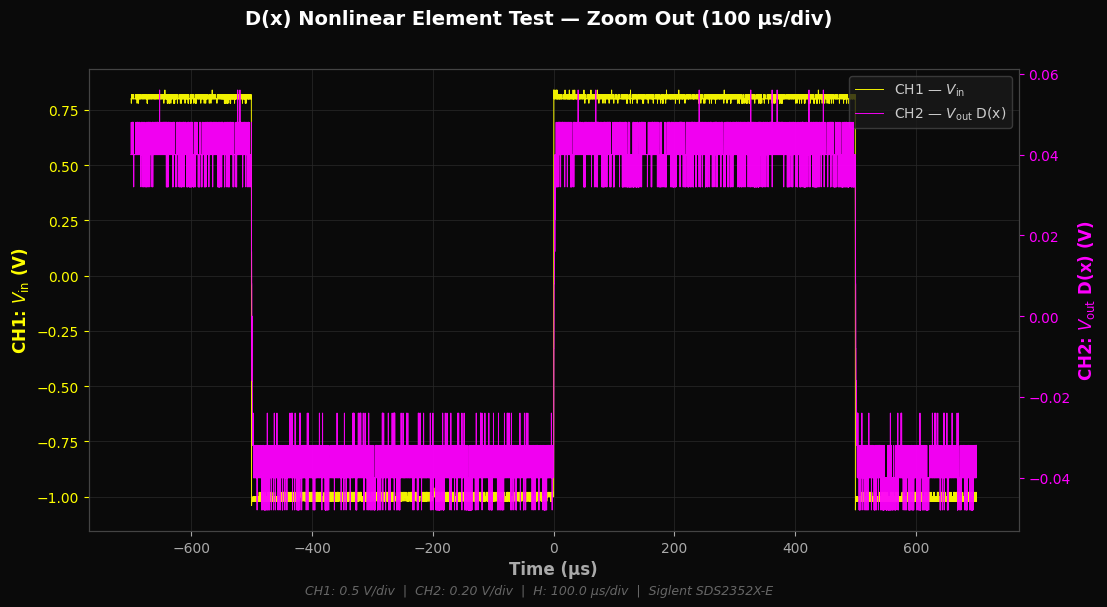

Saved -> D:\Documents\SFU\PHYS382-AdvancedLab\phys332w-sfu-GIT\phys332W-sfu\Lab3-Chaotic-Circuits\Analysis\figures\Session3\Dx-Nonlinear-Test_Zoom-Out_CH1-Vin_CH2-Vout_100us-div.png


In [3]:
# Zoom-out: 1.4M points — downsample by 100 for plotting
plot_oscilloscope(
    df_out, meta_out,
    title="D(x) Nonlinear Element Test — Zoom Out (100 µs/div)",
    save_name="Dx-Nonlinear-Test_Zoom-Out_CH1-Vin_CH2-Vout_100us-div.png",
    downsample=100
)

## Plot 2 — D(x) Test: Zoom-In (Detail View, 0.1 µs/div)\nHigh time-resolution capture showing the fine structure of the D(x) response.

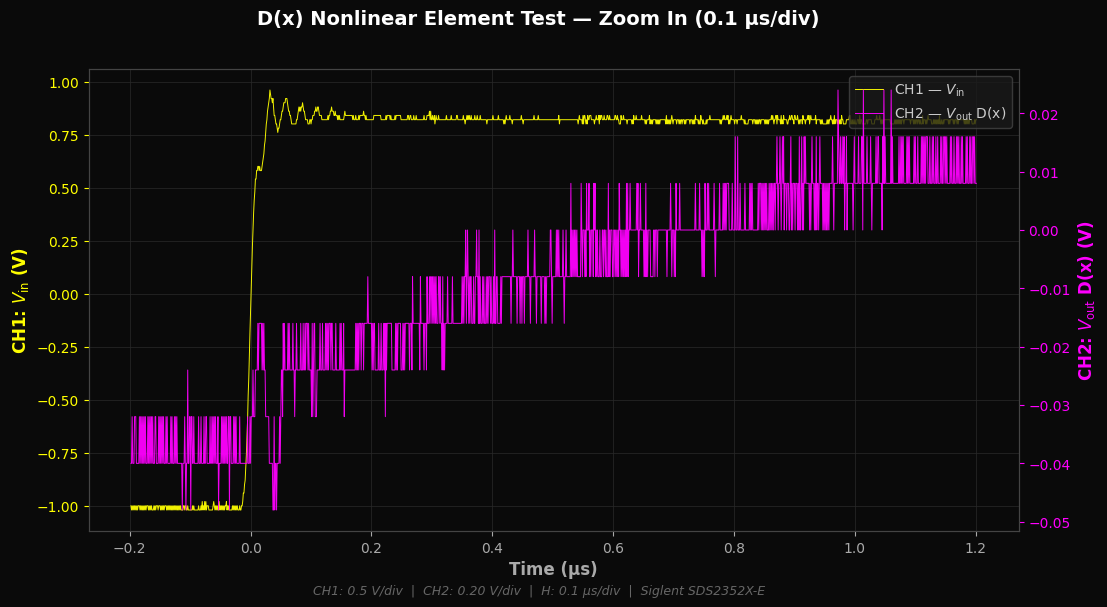

Saved -> D:\Documents\SFU\PHYS382-AdvancedLab\phys332w-sfu-GIT\phys332W-sfu\Lab3-Chaotic-Circuits\Analysis\figures\Session3\Dx-Nonlinear-Test_Zoom-In_CH1-Vin_CH2-Vout_0.1us-div.png


In [4]:
# Zoom-in: 1400 points — no downsampling needed
plot_oscilloscope(
    df_in, meta_in,
    title="D(x) Nonlinear Element Test — Zoom In (0.1 µs/div)",
    save_name="Dx-Nonlinear-Test_Zoom-In_CH1-Vin_CH2-Vout_0.1us-div.png",
    downsample=1
)

## Plot 3 — Section 1 Integrator: Error Trace (SDS00001)\nFirst attempt at testing Section 1 integrator. CH1 = V_in (sine, 1 kHz), CH2 = V_out.\nThis trace was suspicious — retaken as SDS00004.

In [5]:
# --- Load Section 1 data files ---
err_file   = DATA_DIR / "Section1-Error-SDS00001.csv"
retake_file = DATA_DIR / "Section1-SDS00004.csv"

df_err, meta_err     = load_siglent_csv(err_file)
df_retake, meta_retake = load_siglent_csv(retake_file)

print("=== Section 1 ERROR (SDS00001) ===")
print(f"  Points: {len(df_err)}, H-scale: {meta_err['h_scale']} µs/div")
print(f"  CH1: {meta_err['v_scale_ch1']} V/div, offset={meta_err['v_offset_ch1']} V")
print(f"  CH2: {meta_err['v_scale_ch2']} V/div, offset={meta_err['v_offset_ch2']} V")
print(f"  CH1 range: [{df_err['CH1_V'].min():.4f}, {df_err['CH1_V'].max():.4f}] V")
print(f"  CH2 range: [{df_err['CH2_V'].min():.4f}, {df_err['CH2_V'].max():.4f}] V")

print("\n=== Section 1 RETAKE (SDS00004) ===")
print(f"  Points: {len(df_retake)}, H-scale: {meta_retake['h_scale']} µs/div")
print(f"  CH1: {meta_retake['v_scale_ch1']} V/div, offset={meta_retake['v_offset_ch1']} V")
print(f"  CH2: {meta_retake['v_scale_ch2']} V/div, offset={meta_retake['v_offset_ch2']} V")
print(f"  CH1 range: [{df_retake['CH1_V'].min():.4f}, {df_retake['CH1_V'].max():.4f}] V")
print(f"  CH2 range: [{df_retake['CH2_V'].min():.4f}, {df_retake['CH2_V'].max():.4f}] V")

=== Section 1 ERROR (SDS00001) ===
  Points: 1400000, H-scale: 2000.0 µs/div
  CH1: 0.5 V/div, offset=0.0 V
  CH2: 0.005 V/div, offset=0.0008 V
  CH1 range: [-0.5400, 0.6200] V
  CH2 range: [-0.0058, 0.0056] V

=== Section 1 RETAKE (SDS00004) ===
  Points: 1400000, H-scale: 200.0 µs/div
  CH1: 0.5 V/div, offset=0.0 V
  CH2: 0.2 V/div, offset=13.164 V
  CH1 range: [-1.0200, 1.0400] V
  CH2 range: [-13.4840, -12.8360] V


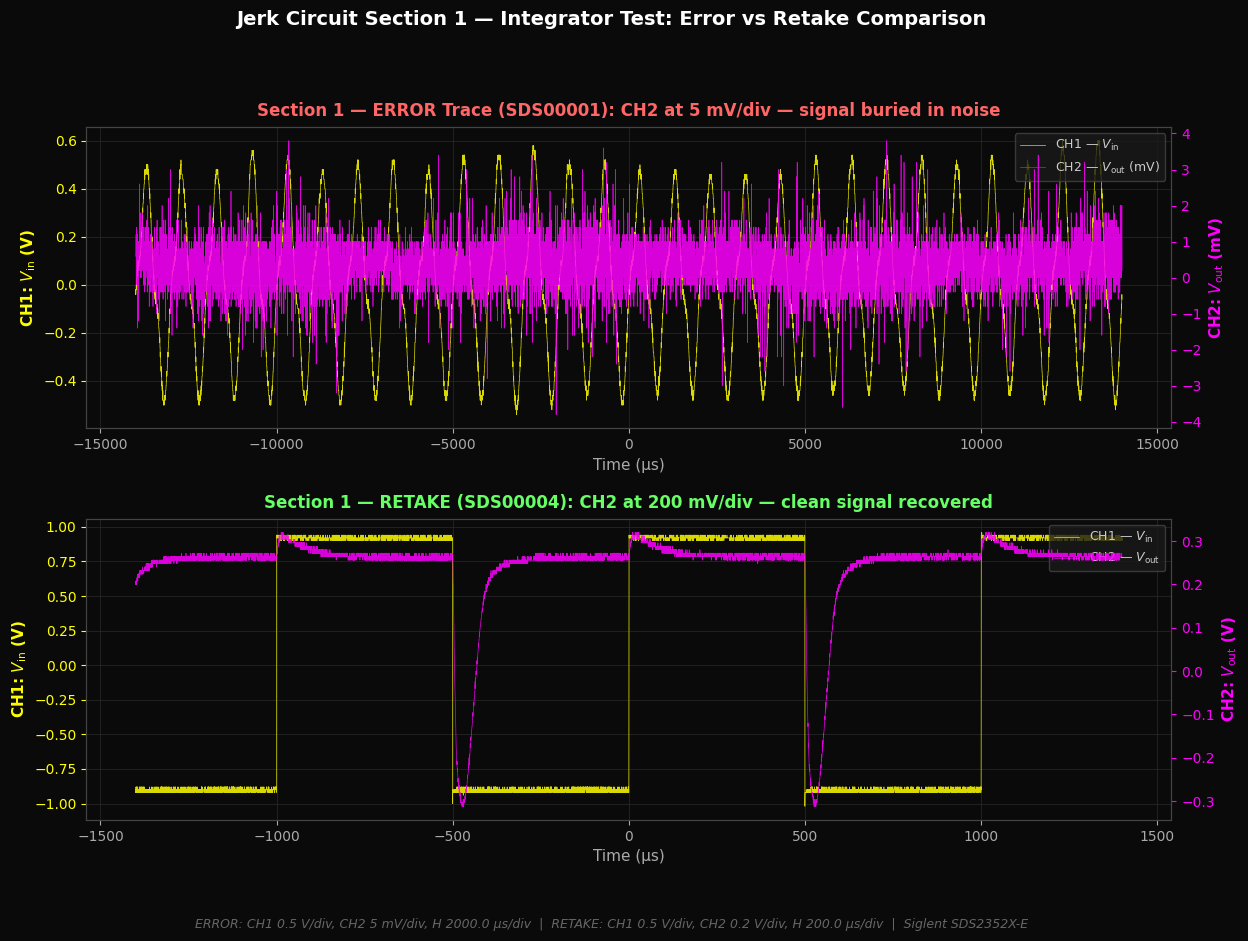


Saved -> D:\Documents\SFU\PHYS382-AdvancedLab\phys332w-sfu-GIT\phys332W-sfu\Lab3-Chaotic-Circuits\Analysis\figures\Session3\Section1-Integrator_Error-vs-Retake_CH1-Vin_CH2-Vout_Comparison.png


In [6]:
# --- Plot both Section 1 traces on the SAME graph ---
# Error trace = faded/dashed, Retake = solid
# Both are 1.4M points — downsample for plotting

ds = 100  # downsample factor

t_err    = df_err['Time_s'].values[::ds] * 1e6
ch1_err  = df_err['CH1_V'].values[::ds]
ch2_err  = df_err['CH2_V'].values[::ds] + meta_err['v_offset_ch2']

t_ret    = df_retake['Time_s'].values[::ds] * 1e6
ch1_ret  = df_retake['CH1_V'].values[::ds]
ch2_ret  = df_retake['CH2_V'].values[::ds] + meta_retake['v_offset_ch2']

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 9), sharex=False,
                                      gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.30})
fig.patch.set_facecolor('#0a0a0a')

for ax in [ax_top, ax_bot]:
    ax.set_facecolor('#0a0a0a')
    ax.grid(True, color='#2a2a2a', linewidth=0.5)
    for spine in ax.spines.values():
        spine.set_color('#444444')
    ax.tick_params(colors='#aaaaaa', labelsize=10)

# ── TOP: ERROR trace (SDS00001) ──
ax_top.plot(t_err, ch1_err, color='#FFFF00', linewidth=0.5, alpha=0.85, label=r'CH1 — $V_{\mathrm{in}}$')
ax_top_r = ax_top.twinx()
ax_top_r.plot(t_err, ch2_err * 1e3, color='#FF00FF', linewidth=0.5, alpha=0.85, label=r'CH2 — $V_{\mathrm{out}}$ (mV)')
ax_top.set_ylabel(r'CH1: $V_{\mathrm{in}}$ (V)', fontsize=11, fontweight='bold', color='#FFFF00')
ax_top_r.set_ylabel(r'CH2: $V_{\mathrm{out}}$ (mV)', fontsize=11, fontweight='bold', color='#FF00FF')
ax_top.tick_params(axis='y', colors='#FFFF00')
ax_top_r.tick_params(axis='y', colors='#FF00FF')
for spine in ax_top_r.spines.values():
    spine.set_color('#444444')
ax_top.set_xlabel('Time (µs)', fontsize=11, color='#aaaaaa')
ax_top.set_title('Section 1 — ERROR Trace (SDS00001): CH2 at 5 mV/div — signal buried in noise',
                  fontsize=12, color='#FF6666', fontweight='bold', pad=8)

lines1, labels1 = ax_top.get_legend_handles_labels()
lines2, labels2 = ax_top_r.get_legend_handles_labels()
ax_top.legend(lines1 + lines2, labels1 + labels2, loc='upper right',
              facecolor='#1a1a1a', edgecolor='#444444', labelcolor='#cccccc', fontsize=9)

# ── BOTTOM: RETAKE trace (SDS00004) ──
ax_bot.plot(t_ret, ch1_ret, color='#FFFF00', linewidth=0.5, alpha=0.85, label=r'CH1 — $V_{\mathrm{in}}$')
ax_bot_r = ax_bot.twinx()
ax_bot_r.plot(t_ret, ch2_ret, color='#FF00FF', linewidth=0.5, alpha=0.85, label=r'CH2 — $V_{\mathrm{out}}$')
ax_bot.set_ylabel(r'CH1: $V_{\mathrm{in}}$ (V)', fontsize=11, fontweight='bold', color='#FFFF00')
ax_bot_r.set_ylabel(r'CH2: $V_{\mathrm{out}}$ (V)', fontsize=11, fontweight='bold', color='#FF00FF')
ax_bot.tick_params(axis='y', colors='#FFFF00')
ax_bot_r.tick_params(axis='y', colors='#FF00FF')
for spine in ax_bot_r.spines.values():
    spine.set_color('#444444')
ax_bot.set_xlabel('Time (µs)', fontsize=11, color='#aaaaaa')
ax_bot.set_title('Section 1 — RETAKE (SDS00004): CH2 at 200 mV/div — clean signal recovered',
                  fontsize=12, color='#66FF66', fontweight='bold', pad=8)

lines3, labels3 = ax_bot.get_legend_handles_labels()
lines4, labels4 = ax_bot_r.get_legend_handles_labels()
ax_bot.legend(lines3 + lines4, labels3 + labels4, loc='upper right',
              facecolor='#1a1a1a', edgecolor='#444444', labelcolor='#cccccc', fontsize=9)

fig.suptitle('Jerk Circuit Section 1 — Integrator Test: Error vs Retake Comparison',
             fontsize=14, color='white', fontweight='bold', y=1.01)

info_err = f'ERROR: CH1 {meta_err["v_scale_ch1"]} V/div, CH2 {meta_err["v_scale_ch2"]*1e3:.0f} mV/div, H {meta_err["h_scale"]} µs/div'
info_ret = f'RETAKE: CH1 {meta_retake["v_scale_ch1"]} V/div, CH2 {meta_retake["v_scale_ch2"]} V/div, H {meta_retake["h_scale"]} µs/div'
fig.text(0.5, -0.01, f'{info_err}  |  {info_ret}  |  Siglent SDS2352X-E',
         ha='center', fontsize=9, color='#666666', style='italic')

save_name = "Section1-Integrator_Error-vs-Retake_CH1-Vin_CH2-Vout_Comparison.png"
plt.savefig(FIG_DIR / save_name, dpi=200, bbox_inches='tight',
            facecolor=fig.get_facecolor(), edgecolor='none')
plt.show()
print(f"\nSaved -> {FIG_DIR / save_name}")